In [2]:
from langgraph.graph import StateGraph
from typing import TypedDict

In [17]:
class ConditionState(TypedDict):
    number1: int
    number2: int
    number3: int
    number4: int
    operator1: str
    operator2: str
    mid_result: int
    final_result: int

In [18]:
def add_node(state: ConditionState) -> ConditionState:
    """加法节点"""
    state["mid_result"] = state["number1"] + state["number2"]
    return state


def add_node2(state: ConditionState) -> ConditionState:
    """加法节点"""
    state["final_result"] = state["number3"] + state["number4"]
    return state

In [19]:
def subtract_node(state: ConditionState) -> ConditionState:
    """减法节点"""
    state["mid_result"] = state["number1"] - state["number2"]
    return state


def subtract_node2(state: ConditionState) -> ConditionState:
    """减法节点"""
    state["final_result"] = state["number3"] - state["number4"]
    return state

In [20]:
def condition_node(state: ConditionState) -> str:
    if state["operator1"] == "+":
        return "add_operation"
    elif state["operator1"] == "-":
        return "subtract_operation"


def condition_node2(state: ConditionState) -> str:
    if state["operator2"] == "+":
        return "add_operation2"
    elif state["operator2"] == "-":
        return "subtract_operation2"

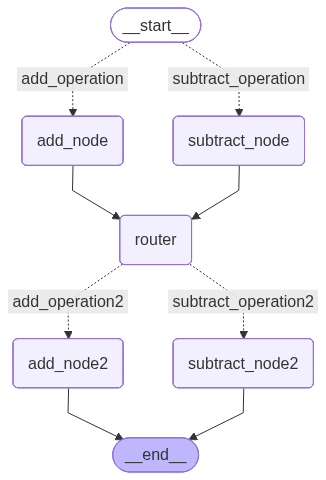

In [21]:
from langgraph.constants import START, END

graph = StateGraph(ConditionState)

graph.add_node("add_node", add_node)
graph.add_node("add_node2", add_node2)
graph.add_node("subtract_node", subtract_node)
graph.add_node("subtract_node2", subtract_node2)
graph.add_node("router", lambda state: state)

# 直接用START充当第一个条件Node
graph.add_conditional_edges(
    START,
    condition_node,
    {
        "add_operation": "add_node",
        "subtract_operation": "subtract_node"
    }
)

graph.add_edge("add_node", "router")
graph.add_edge("subtract_node", "router")

graph.add_conditional_edges(
    "router",
    condition_node2,
    {
        "add_operation2": "add_node2",
        "subtract_operation2": "subtract_node2"
    }
)

graph.add_edge("add_node2", END)
graph.add_edge("subtract_node2", END)

graph.compile()

In [22]:
app = graph.compile()

In [23]:
app.invoke({"number1": 5, "number2": 6, "number3": 7, "number4": 8,"operator1": "+", "operator2": "-"})

{'number1': 5,
 'number2': 6,
 'number3': 7,
 'number4': 8,
 'operator1': '+',
 'operator2': '-',
 'mid_result': 11,
 'final_result': -1}